# `torchdyn`Quickstart

`torchdyn` is a PyTorch library dedicated to neural differential equations and equilibrium models.

Central to the `torchdyn` approach are continuous and implicit neural networks, where *depth* is taken to its infinite limit.

This notebook serves as a gentle introduction to NeuralODE, concluding with a small overview of `torchdyn` features.

In [ ]:
!pip install torchdyn

In [4]:
import torch
from torchdyn.models import NeuralODE
from torchdyn.datasets import ToyDataset
from torchdyn.core import ODEProblem

from torchdyn.core import NeuralODE
from torchdyn.models import CNF
from torchdyn.nn import DataControl, DepthCat, Augmenter
from torchdyn.datasets import *
from torchdyn.utils import *

import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# import cv2

In [ ]:

def load_png_to_binary_image(png_path, shape=(1000, 1000)):

    png_image = Image.open(png_path).convert("L")
    png_image = png_image.resize(shape, Image.ANTIALIAS)
    numpy_image = np.array(png_image)
    _, binary_image = cv2.threshold(numpy_image, 127, 255, cv2.THRESH_BINARY)
    binary_image = binary_image // 255
    return binary_image

png_path = "/content/maze (5).png"
binary_image = load_png_to_binary_image(png_path)
binary_image.shape
import heapq

def fast_marching_method(binary_image):
    # Initialize SDF with large positive and negative values
    sdf = np.where(binary_image == 1, float('inf'), -float('inf'))

    # Initialize a priority queue and add boundary pixels with zero distance
    heap = []
    for x in range(1, binary_image.shape[0] - 1):
        for y in range(1, binary_image.shape[1] - 1):
            if binary_image[x, y] != binary_image[x + 1, y] or \
               binary_image[x, y] != binary_image[x - 1, y] or \
               binary_image[x, y] != binary_image[x, y + 1] or \
               binary_image[x, y] != binary_image[x, y - 1]:
                sdf[x, y] = 0
                heapq.heappush(heap, (0, (x, y)))

    # Update SDF values using the Fast Marching Method
    while heap:
        distance, (x, y) = heapq.heappop(heap)
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                x_neighbor, y_neighbor = x + dx, y + dy
                if 0 <= x_neighbor < binary_image.shape[0] and 0 <= y_neighbor < binary_image.shape[1]:
                    new_distance = distance + np.sqrt(dx ** 2 + dy ** 2)
                    if new_distance < abs(sdf[x_neighbor, y_neighbor]):
                        sdf[x_neighbor, y_neighbor] = new_distance if binary_image[x_neighbor, y_neighbor] == 1 else -new_distance
                        heapq.heappush(heap, (new_distance, (x_neighbor, y_neighbor)))

    return sdf

# Calculate the SDF using Fast Marching Method
sdf_fmm = fast_marching_method(binary_image)

# Display the SDF
plt.imshow(sdf_fmm, cmap='RdBu')
plt.title('Signed Distance Function (Fast Marching Method)')
plt.axis('off')
plt.colorbar(label='Distance')
plt.show()

def apply_sharp_sigmoid(array, k=0.000, x0=0):
    if k == 0:
        return array
    return 1 / (1 + np.exp(-k * (array - x0)))

# Apply sharp sigmoid to the SDF of the PNG image
sdf_fmm_png_sigmoid = apply_sharp_sigmoid(sdf_fmm, k=0, x0=0)
sdf_fmm_png_sigmoid_sharper = apply_sharp_sigmoid(sdf_fmm, k=1, x0=0)

def sdf_unit_circle(x, y):
    return 1 - torch.sqrt(x**2 + y**2)


In [ ]:
# Assuming sdf_fmm_png_sigmoid is defined and is a 1000x1000 NumPy array
# For demonstration, using a random array
class SDF_Loss_Interpolated(nn.Module):
    def __init__(self, sdf_array, device='cpu'):
        super(SDF_Loss_Interpolated, self).__init__()
        self.sdf_array = torch.tensor(sdf_array, dtype=torch.float32).to(device)
        self.device = device

    def bilinear_interpolation(self, x, y, report = False):
        x1, y1 = torch.floor(x).long(), torch.floor(y).long()
        x2, y2 = x1 + 1, y1 + 1

        # Bounds checking
        max_x, max_y = self.sdf_array.shape[0] - 1, self.sdf_array.shape[1] - 1
        x1, x2 = torch.clamp(x1, 0, max_x), torch.clamp(x2, 0, max_x)
        y1, y2 = torch.clamp(y1, 0, max_y), torch.clamp(y2, 0, max_y)

        # Interpolation weights
        t = (x - x1.float()).to(self.device)
        u = (y - y1.float()).to(self.device)

        if report:
            print(f"Interpolation between: {x1.item(), y1.item()} and {x2.item(), y2.item()}")
            print(f"Interpolation weights: {t.item(), u.item()}")
            print(f"Interpolation values: {self.sdf_array[x1, y1].item(), self.sdf_array[x2, y1].item(), self.sdf_array[x1, y2].item(), self.sdf_array[x2, y2].item()}")

        sdf_values = (1 - t) * (1 - u) * self.sdf_array[x1, y1] + \
                     t * (1 - u) * self.sdf_array[x2, y1] + \
                     (1 - t) * u * self.sdf_array[x1, y2] + \
                     t * u * self.sdf_array[x2, y2]

        return sdf_values

    def forward(self, x, y):
        report = False
        if x.shape == torch.Size([]):
            print(x,y)
            report = False
        sdf_values = torch.clamp(self.bilinear_interpolation(x, y, report = report), -1000, 0)

        # Sample loss computation
        loss = torch.sum(sdf_values)

        return loss, sdf_values

# Instantiate the loss class
device = 'cuda:0'
sdf_loss_function_interpolated = SDF_Loss_Interpolated(sdf_fmm_png_sigmoid, device=device)
sdf_loss_function_interpolated_sharper = SDF_Loss_Interpolated(sdf_fmm_png_sigmoid_sharper, device=device)


In [ ]:
def sdf_loss_function_interpolated(x, y):
    return (torch.sqrt(x**2 + y**2) - 1).sum(), torch.sqrt(x**2 + y**2) - 1

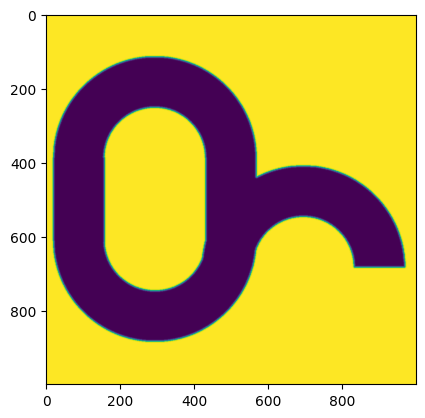

/usr/local/lib/python3.10/dist-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
<ipython-input-6-1e3b213b0969>:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  _, loss = sdf_loss_function_interpolated(torch.tensor(X), torch.tensor(Y))


(tensor(805.6230), tensor(805.6230))  RED
(tensor(223.1435), tensor(223.1435))  GREEN


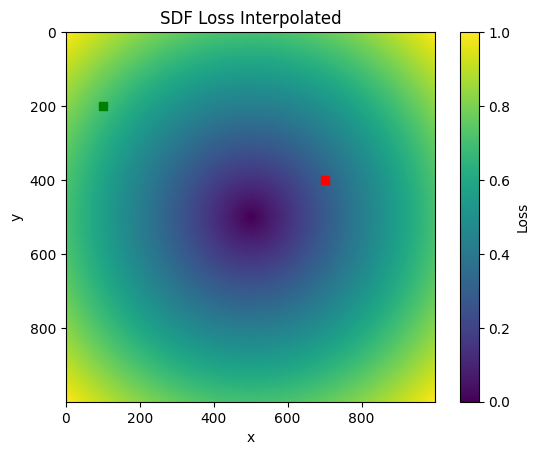

In [ ]:
# RED # GOAL
a = 700.
b = 400.8
# GREEN # START
x = 100.2
y = 200.5

plt.imshow(sdf_fmm_png_sigmoid_sharper, cmap='viridis')
# plt.title('Transformed SDF (Sharp Sigmoid Applied)')
# plt.scatter(100*x, 100*y, c='g', label='Start')
# plt.axis('on')
# plt.colorbar(label='Transformed Distance')
plt.show()

# Create a meshgrid of x and y
x1 = torch.linspace(-100, 100, 1000)
y1 = torch.linspace(-100, 100, 1000)
X, Y = torch.meshgrid(x1, y1)

# Evaluate the loss function on the meshgrid
_, loss = sdf_loss_function_interpolated(torch.tensor(X), torch.tensor(Y))
loss = loss.detach().cpu().numpy()
# Plot the loss function
plt.imshow(loss, cmap='viridis')
plt.scatter(x, y, c='g', label='Start', marker = 's')

plt.scatter(a, b, c='r', label='Goal', marker = 's')
plt.title('SDF Loss Interpolated')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Loss')
print(sdf_loss_function_interpolated(torch.tensor(b), torch.tensor(a)), " RED")
print(sdf_loss_function_interpolated(torch.tensor(y), torch.tensor(x)), " GREEN")
plt.show()



In [ ]:

def plot_flow_field(ode_function, xlim, ylim, num_points=20):
 # Generate a grid of points
    x = np.linspace(xlim[0], xlim[1], num_points)
    y = np.linspace(ylim[0], ylim[1], num_points)
    X, Y = np.meshgrid(x, y)

    # Compute the flow at each point
    U, V = np.zeros(X.shape), np.zeros(Y.shape)
    for i in range(num_points):
        for j in range(num_points):
            input_tensor = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32).to('cuda:0')
            output_tensor = ode_function(input_tensor)
            U[i, j], V[i, j] = output_tensor.cpu().detach().numpy()[0]

    # Plotting the quiver
    plt.figure(figsize=(10, 10))
    plt.quiver(X, Y, U, V, color='black')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Quiver Plot of ODEF')
    plt.grid()

In [ ]:
class ODEF(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 64),
                                 nn.Tanh(),
                                 nn.Linear(64, 2))

    def forward(self, x):
        a, sdf_values = sdf_loss_function_interpolated((1*x[-1][1]), (1*x[-1][0]))
        # sdf_values = sdf_disc(x[:, 0], x[:, 1]).unsqueeze(1)
        print("Currently querying point", list(x), " which is ", list(100*x), " which gives ", sdf_values)
        return self.net(x) * (sdf_values)

def init_weights(m):
    if type(m) == nn.Linear:
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

############

class MaskedODEF(nn.Module):
    def __init__(self, original_ode, sdf_array = sdf_fmm_png_sigmoid_sharper):
        super().__init__()
        self.original_ode = original_ode
        self.sdf_array = torch.tensor(sdf_array).float().cuda()  # Convert numpy array to PyTorch tensor
        self.device = 'cuda:0'

    def bilinear_interpolation(self, x, y):
        x1, y1 = torch.floor(x).long(), torch.floor(y).long()
        x2, y2 = x1 + 1, y1 + 1

        # Bounds checking
        max_x, max_y = self.sdf_array.shape[0] - 1, self.sdf_array.shape[1] - 1
        x1, x2 = torch.clamp(x1, 0, max_x), torch.clamp(x2, 0, max_x)
        y1, y2 = torch.clamp(y1, 0, max_y), torch.clamp(y2, 0, max_y)

        # Interpolation weights
        t = (x - x1.float()).to(self.device)
        u = (y - y1.float()).to(self.device)

        sdf_values = (1 - t) * (1 - u) * self.sdf_array[x1, y1] + \
                     t * (1 - u) * self.sdf_array[x2, y1] + \
                     (1 - t) * u * self.sdf_array[x1, y2] + \
                     t * u * self.sdf_array[x2, y2]

        return sdf_values

    def forward(self, x):
        flow = self.original_ode(x)
        x, y = x.split(1, dim=-1)

        mask = self.bilinear_interpolation(x, y)
        masked_flow = flow * mask

        return masked_flow

original_ode = ODEF().cuda()
masked_ode = MaskedODEF(original_ode)
f = NeuralODE(original_ode, sensitivity='adjoint', solver='rk4').cuda()


f = ODEF()
f.apply(init_weights)

# f = MaskedODEF(original_ode)
neural_ode = NeuralODE(f, sensitivity='adjoint', solver='rk4', ).to('cuda:0')

A = torch.tensor([[a, b]]).cuda()
A_prime = torch.tensor([[x, y]]).cuda()

k = 50
def loss_fn(traj_A):
    loss_A = torch.nn.functional.mse_loss(100*traj_A[-1], 100*A_prime)
    loss_B, loss_trajectory_sdf = sdf_loss_function_interpolated(100*traj_A[-k:, 0, 1], 100*traj_A[-k:, 0, 0])
    # Inside is positive, outside negative
    loss_B_sharp, loss_sharp_max = sdf_loss_function_interpolated_sharper(100*traj_A[-k:-1, 0, 1], 100*traj_A[-k:-1, 0, 0])
    # Inside is 1, outside 0
    # interiority_loss = (torch.min(loss_trajectory_sdf))
    # Calculate curvature regularization term
    dx = traj_A[1:, 0, 0] - traj_A[:-1, 0, 0]
    dy = traj_A[1:, 0, 1] - traj_A[:-1, 0, 1]

    ddx = dx[1:] - dx[:-1]
    ddy = dy[1:] - dy[:-1]

    curvature = (dx[:-1] * ddy - dy[:-1] * ddx) / torch.pow((dx[:-1]**2 + dy[:-1]**2), 1.5)
    curvature_loss = -torch.sum(torch.abs(curvature))  # We aim to maximize the absolute curvature

    length_loss = torch.sum(torch.sqrt(dx**2 + dy**2))
    interiority_loss = torch.max(torch.sqrt(dx**2 + dy**2)) - torch.min(torch.sqrt(dx**2 + dy**2))

    total_loss = loss_A + loss_B + 0.8 * curvature_loss + length_loss # 0.1 is a hyperparameter, can be adjusted

    return length_loss, loss_A, loss_B, curvature_loss, interiority_loss, length_loss


Your vector field callable (nn.Module) should have both time `t` and state `x` as arguments, we've wrapped it for you.
Your vector field callable (nn.Module) should have both time `t` and state `x` as arguments, we've wrapped it for you.


In [ ]:
def show():
    with torch.no_grad():  # Ensure no gradients are computed during this
        # Generate a trajectory from the start point
        plot_flow_field(original_ode.net, [0, 1000], [0, 1000])
        traj_A = neural_ode.trajectory(A, t_span).cpu().numpy()

        # Plot the SDF field
        # plt.imshow(sdf_fmm_png_sigmoid_sharper, cmap='viridis', extent=[0, 1000, 0, 1000])
        # plt.colorbar(label='Transformed Distance')

        # Extract x and y coordinates from the trajectory
        x_traj, y_traj = traj_A[:, 0, 0], traj_A[:, 0, 1]
        plt.plot(100 * x_traj, 100 * y_traj, '-o', color='red', label='Trajectory')

        # Plot start and end points
        plt.scatter(100 * A[0, 1].detach().cpu(), 100 * A[0, 0].detach().cpu(), color='green', marker='s', label='Start')
        plt.scatter(100 * A_prime[0, 1].detach().cpu(), 100 * A_prime[0, 0].detach().cpu(), color='blue', marker='s', label='Goal')

        # Add labels and legend
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'Trajectory at Epoch {epoch}')
        plt.legend()

        plt.show()


  0%|          | 0/10 [00:00<?, ?it/s]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([684.4794, 400.1544], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([68447.9375, 40015.4375], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(791.8654, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([684.7444, 400.1654], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([68474.4453, 40016.5430], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(792.0999, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([669.4798, 399.5305], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([66947.9766, 39953.0469], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(778.6331, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([669.

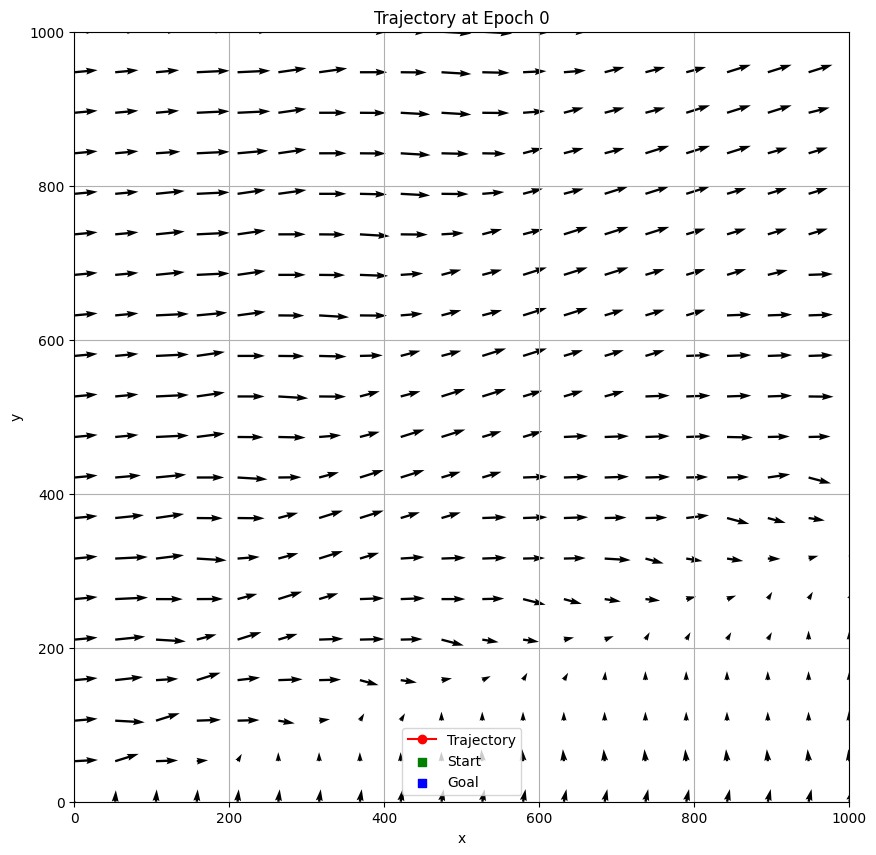

 10%|█         | 1/10 [00:03<00:28,  3.22s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([677.7040, 394.5742], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67770.4062, 39457.4180], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(783.2012, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([678.4353, 394.7959], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67843.5312, 39479.5938], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(783.9448, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([656.8139, 388.7736], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([65681.3906, 38877.3555], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(762.2492, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([657.

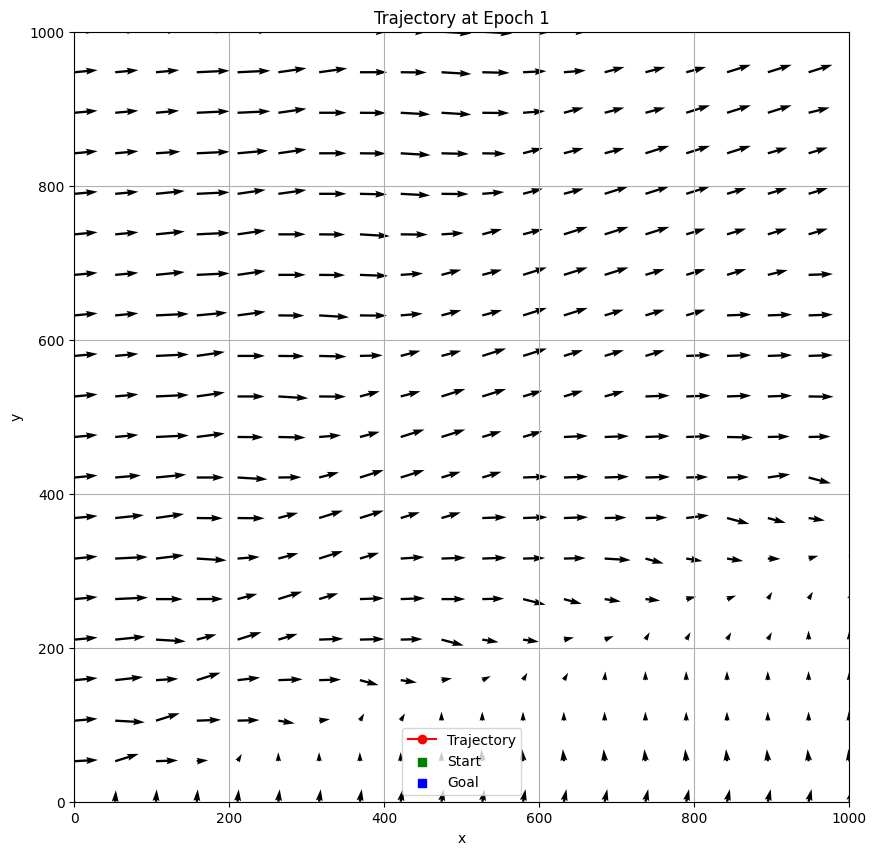

 20%|██        | 2/10 [00:05<00:21,  2.68s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([677.1371, 392.8796], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67713.7109, 39287.9648], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(781.8595, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([677.8115, 393.1133], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67781.1484, 39311.3281], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(782.5601, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([655.5832, 385.4128], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([65558.3203, 38541.2773], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(759.4816, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([655.

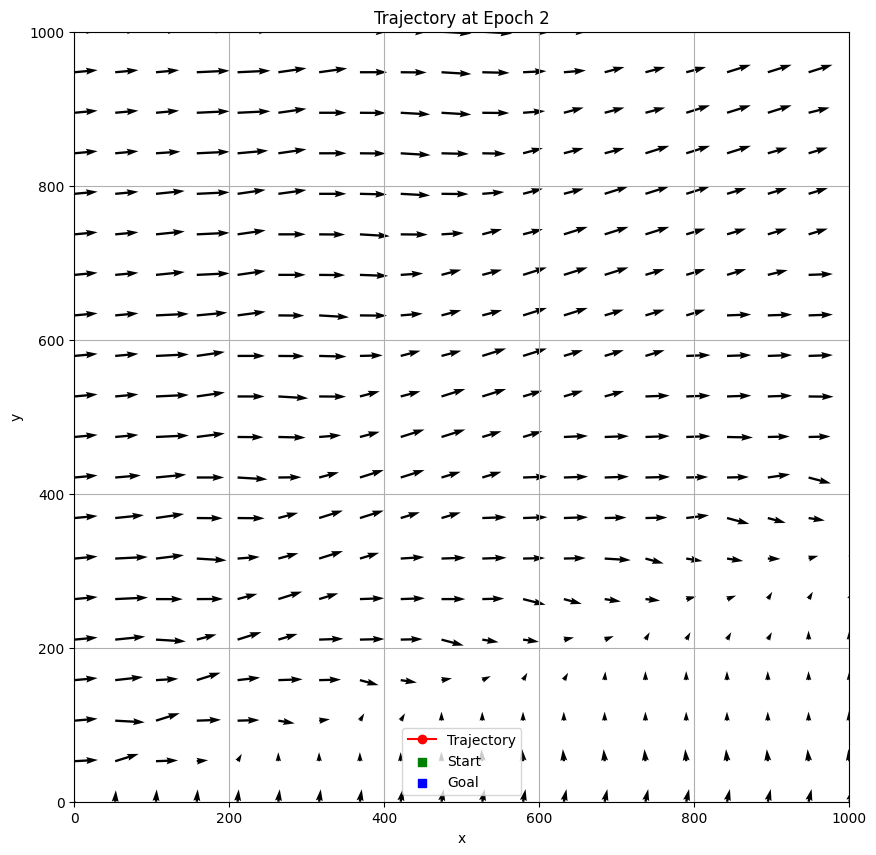

 30%|███       | 3/10 [00:07<00:16,  2.40s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([674.8689, 390.9221], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67486.8906, 39092.2148], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(778.9155, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([675.7001, 391.2446], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67570.0078, 39124.4570], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(779.7963, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([651.3453, 381.6678], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([65134.5352, 38166.7812], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(753.9312, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([651.

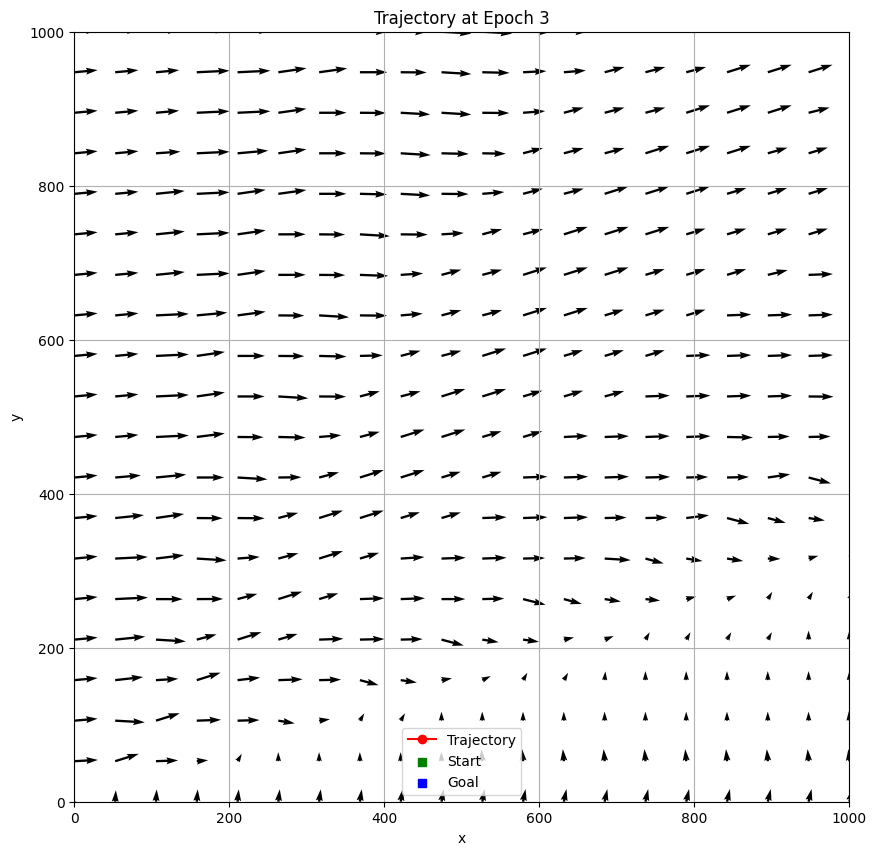

 40%|████      | 4/10 [00:09<00:13,  2.30s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([674.4768, 393.1356], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67447.6797, 39313.5625], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(779.6885, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([675.2980, 393.3813], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67529.8047, 39338.1328], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(780.5218, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([650.5433, 385.9469], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([65054.3320, 38594.6914], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(755.4136, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([650.

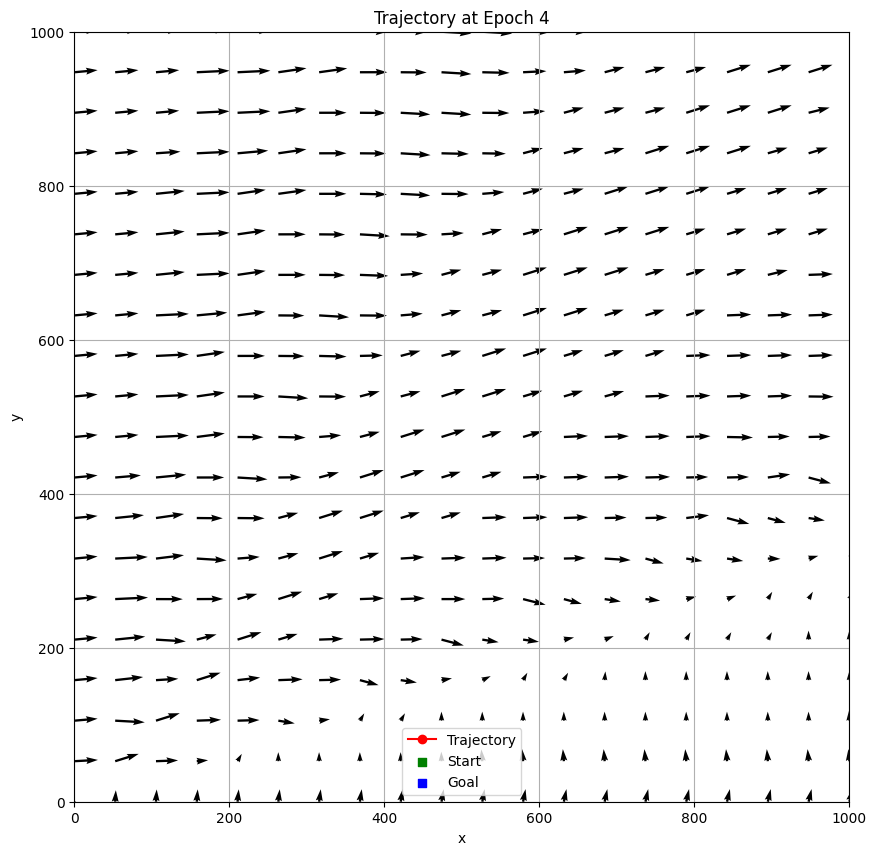

 50%|█████     | 5/10 [00:11<00:11,  2.25s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([672.9561, 392.0419], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67295.6094, 39204.1875], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(777.8240, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([673.8893, 392.3441], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67388.9375, 39234.4102], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(778.7825, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([647.7143, 383.8673], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([64771.4297, 38386.7344], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(751.9196, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([647.

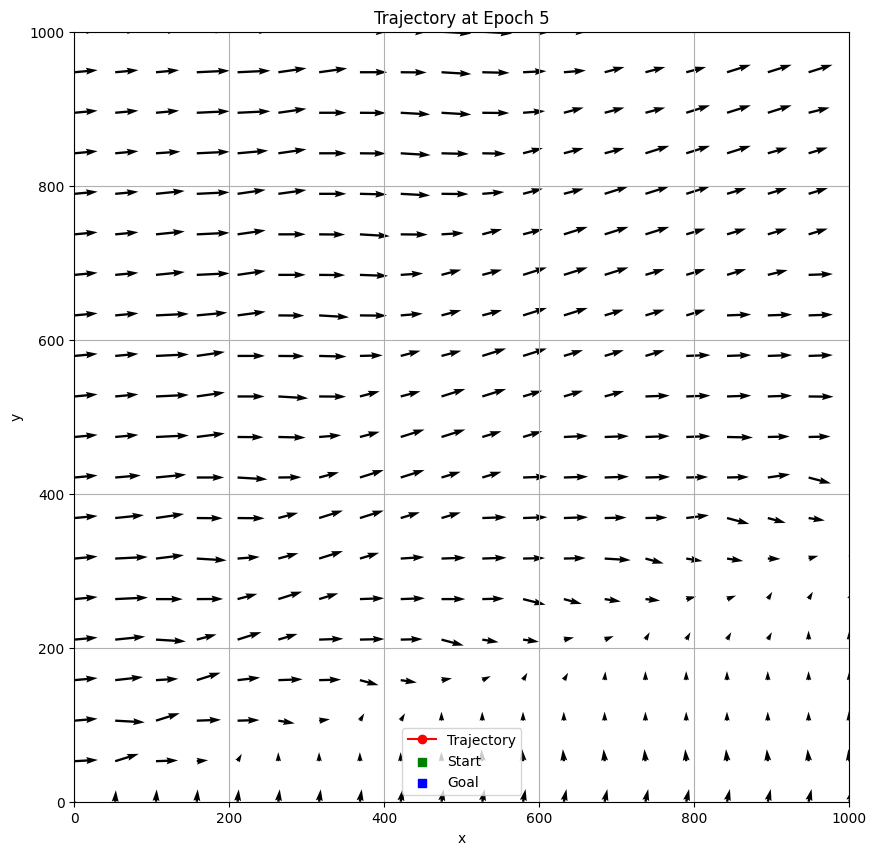

 60%|██████    | 6/10 [00:13<00:08,  2.20s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([671.6126, 391.1950], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67161.2578, 39119.5039], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(776.2368, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([672.6481, 391.5454], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67264.8047, 39154.5391], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(777.3079, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([645.2207, 382.2653], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([64522.0703, 38226.5273], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(748.9576, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([645.

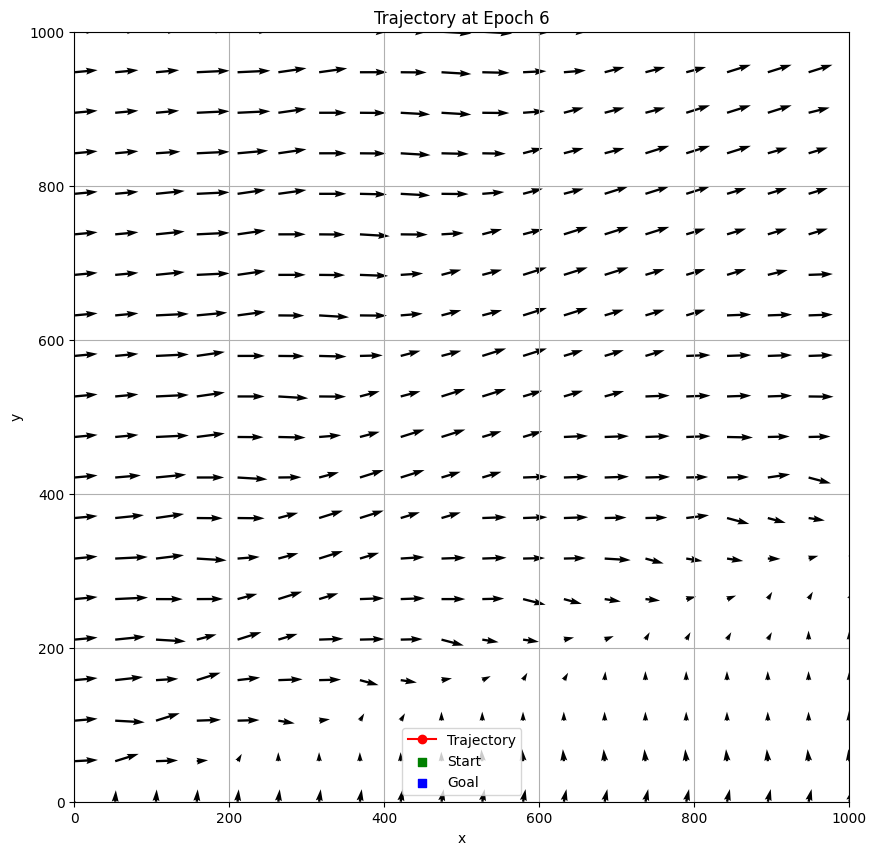

 70%|███████   | 7/10 [00:16<00:06,  2.22s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([670.1367, 390.7497], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67013.6641, 39074.9727], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(774.7374, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([671.2816, 391.1350], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67128.1562, 39113.5000], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(775.9205, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([642.4754, 381.4406], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([64247.5391, 38144.0547], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(746.1757, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([642.

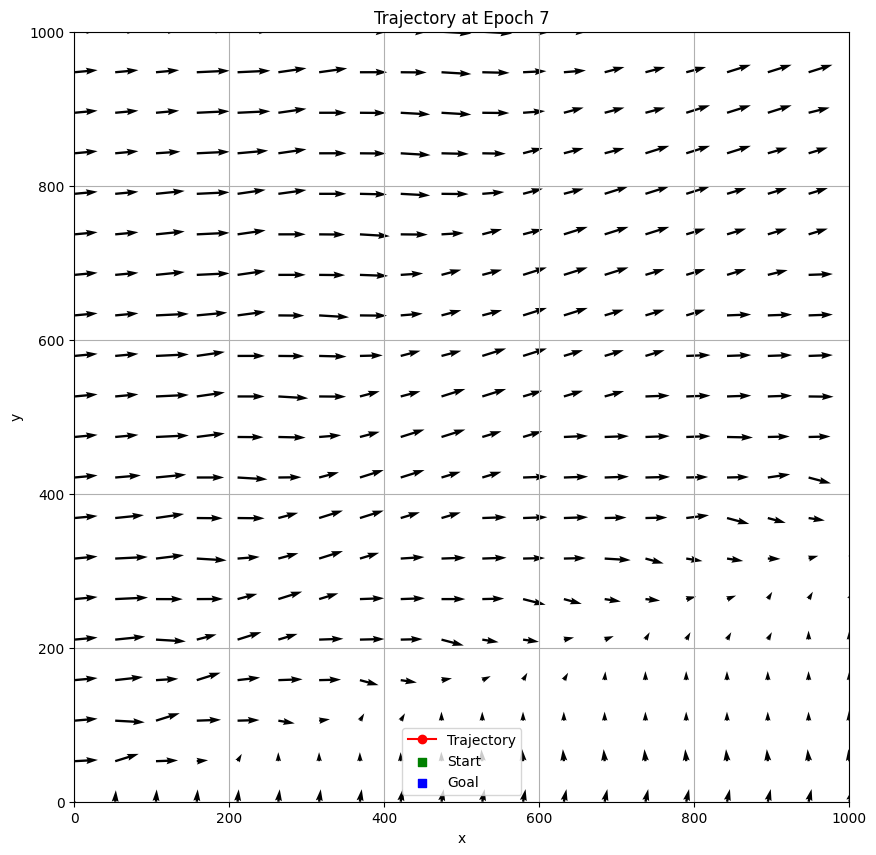

 80%|████████  | 8/10 [00:18<00:04,  2.24s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([668.8182, 390.4212], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([66881.8203, 39042.1250], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(773.4330, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([670.0641, 390.8359], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([67006.4141, 39083.5938], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(774.7182, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([640.0287, 380.8388], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([64002.8750, 38083.8789], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(743.7651, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([640.

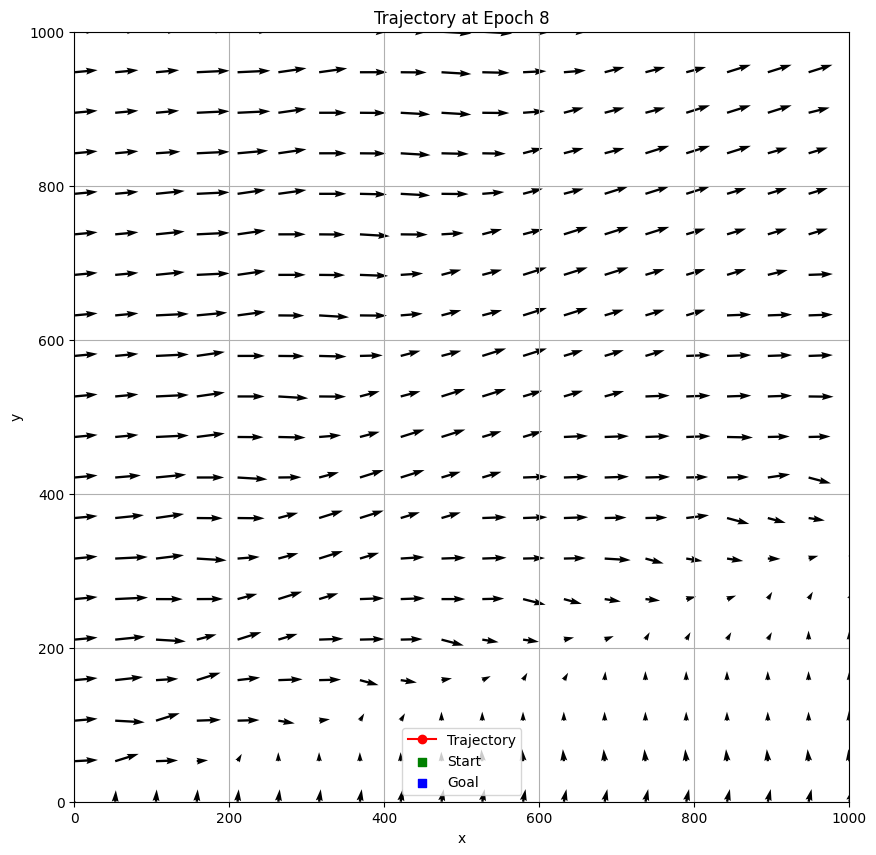

 90%|█████████ | 9/10 [00:20<00:02,  2.21s/it]

Currently querying point [tensor([700.0000, 400.8000], device='cuda:0')]  which is  [tensor([70000., 40080.], device='cuda:0')]  which gives  tensor(805.6230, device='cuda:0')
Currently querying point [tensor([667.9711, 389.7622], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([66797.1094, 38976.2227], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(772.3692, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([669.2931, 390.2179], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([66929.3125, 39021.7852], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(773.7408, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([638.4772, 379.5981], device='cuda:0', grad_fn=<UnbindBackward0>)]  which is  [tensor([63847.7188, 37959.8125], device='cuda:0', grad_fn=<UnbindBackward0>)]  which gives  tensor(741.7973, device='cuda:0', grad_fn=<SubBackward0>)
Currently querying point [tensor([638.

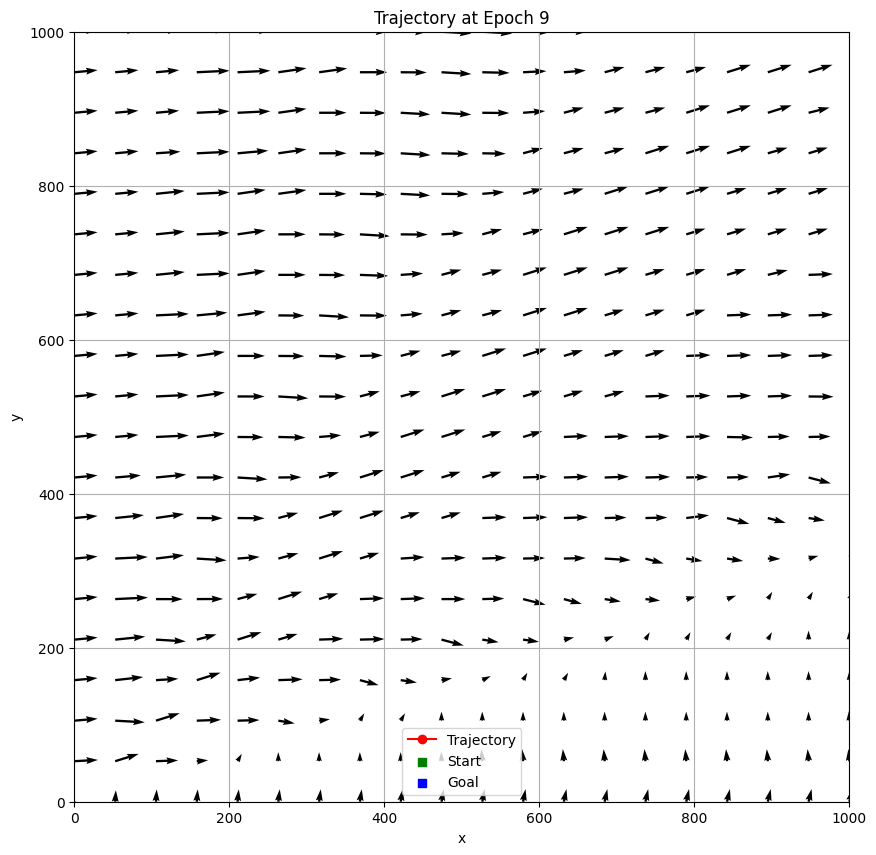

100%|██████████| 10/10 [00:22<00:00,  2.28s/it]


In [ ]:
optimizer = torch.optim.Adam(neural_ode.parameters(), lr=0.01)
n_epochs = 10
t_span = torch.linspace(0, 1, k)  # assuming t1=1 for simplicity, adjust as needed
sdf_threshold = 0.1
from tqdm import tqdm
for epoch in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    traj_A = neural_ode.trajectory(A, t_span)

    length_loss, loss_reach, loss_sdf, loss_curv, loss_interiority, loss_length = loss_fn(traj_A)

    # # if loss_sdf < sdf_threshold:
    # if loss_reach < 1000 and loss_sdf > 0:
    #     regime = "home-in"
    #     loss = loss_reach - loss_sdf
    # else:
    #     regime = "explore"
    #     loss = -500*loss_length - 1e6*loss_sdf + 50*loss_curv

    loss = loss_reach # 2000 * loss_curv + loss_sdf

    # if loss_reach > 1000:
    #     regime = "home-in"
    #     loss = loss_reach
    # else:
    #     regime = "anneal"
    #     loss = 1e6*loss_reach + 500*loss_curv - 10*loss_length

    # else:
    #     loss = loss_sdf

    loss.backward()
    # torch.nn.utils.clip_grad_norm_(neural_ode.parameters(), max_norm=1)
    optimizer.step()

    if epoch % 1 == 0:
        # print(f"Epoch {epoch}: Loss {loss.item()} Loss Reach {loss_reach.item()} Loss SDF {loss_sdf.item()} Loss Curv {loss_curv.item()} Interiority Loss {loss_interiority.item()}")
        # print(regime)
        show()


In [ ]:
from torchdyn.core import NeuralODE
from torchdyn.datasets import *
from torchdyn import *
import torch
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [ ]:
# quick run for automated notebook validation
dry_run = False

## Generate data from a static toy dataset

We’ll be generating data from toy datasets. In torchdyn, we provide a wide range of datasets often use to benchmark and understand Neural ODEs. Here we will use the classic moons dataset and train a Neural ODE for binary classification

In [ ]:
d = ToyDataset()
X, yn = d.generate(n_samples=512, noise=1e-1, dataset_type='moons')

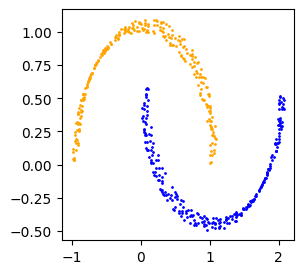

In [ ]:
import matplotlib.pyplot as plt

colors = ['orange', 'blue']
fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot(111)
for i in range(len(X)):
    ax.scatter(X[i,0], X[i,1], s=1, color=colors[yn[i].int()])

Generated data can be easily loaded in the dataloader with standard `PyTorch` calls

In [ ]:
import torch
import torch.utils.data as data
device = torch.device("cpu") # all of this works in GPU as well :)

X_train = torch.Tensor(X).to(device)
y_train = torch.LongTensor(yn.long()).to(device)
train = data.TensorDataset(X_train, y_train)
trainloader = data.DataLoader(train, batch_size=len(X), shuffle=True)

We utilize [Pytorch Lightning](https://github.com/PyTorchLightning/pytorch-lightning) to handle training loops, logging and general bookkeeping. This allows `torchdyn` and Neural Differential Equations to have access to modern best practices for training and experiment reproducibility.

In particular, we combine modular `torchdyn` models with `LightningModules` via a `Learner` class:

In [ ]:
import torch.nn as nn
import pytorch_lightning as pl

class Learner(pl.LightningModule):
    def __init__(self, t_span:torch.Tensor, model:nn.Module):
        super().__init__()
        self.model, self.t_span = model, t_span

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        t_eval, y_hat = self.model(x, self.t_span)
        y_hat = y_hat[-1] # select last point of solution trajectory
        loss = nn.CrossEntropyLoss()(y_hat, y)
        return {'loss': loss}

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(), lr=0.01)

    def train_dataloader(self):
        return trainloader

## Define a  Neural ODE

Analogously to most forward neural models we want to realize a map

$$
        x \mapsto \hat y
$$

where  $\hat y$ becomes the best approximation of a true output $y$ given an input $x$.
In torchdyn you can define very simple Neural ODE models of the form

$$ \left\{
    \begin{aligned}
        \dot{z}(t) &= f(z(t), \theta)\\
        z(0) &= x\\
        \hat y & = z(1)
    \end{aligned}
    \right. \quad t\in[0,1]
$$

by just specifying a neural network $f$ and giving some simple settings.

**Note:** This Neural ODE model is of *depth-invariant* type as neither $f$ explicitly depend on $s$ nor the parameters $\theta$ are depth-varying. Together with their *depth-variant* counterpart with $s$ concatenated in the vector field was first proposed and implemented by [[Chen T. Q. et al, 2018]](https://arxiv.org/abs/1806.07366)

### Define the vector field (DEFunc)

The first step is to define any PyTorch `torch.nn.Module`. This takes the role of the Neural ODE vector field $f(h,\theta)$

In this case we chose $f$ to be a simple MLP with one hidden layer and $\tanh$ activation

### Define the NeuralDE

The final step to define a Neural ODE is to instantiate the torchdyn's class `NeuralDE` passing some customization arguments and `f` itself.

In this case we specify:
* we compute backward gradients with the `'adjoint'` method.
* we will use the `'dopri5'` (Dormand-Prince) ODE solver from `torchdyn`, with no additional options;

In [ ]:
# model = NeuralODE(f, sensitivity='adjoint', solver='dopri5').to(device)

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

def load_png_to_binary_image(png_path, shape=(90, 90)):

    png_image = Image.open(png_path).convert("L")
    png_image = png_image.resize(shape, Image.Resampling.LANCZOS)
    numpy_image = np.array(png_image)
    _, binary_image = cv2.threshold(numpy_image, 127, 255, cv2.THRESH_BINARY)
    binary_image = binary_image // 255
    return binary_image

png_path = "/content/maze (5).png"
binary_image = load_png_to_binary_image(png_path)

## Train the Model

With the same forward method of `NeuralDE` objects you can quickly evaluate the entire trajectory of each data point in `X_train` on an interval `t_span`

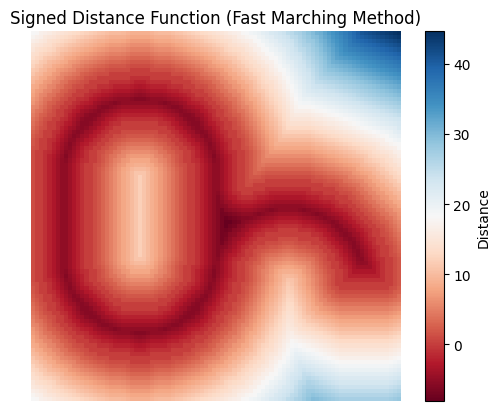

In [ ]:
import heapq
c

# Calculate the SDF using Fast Marching Method
sdf_fmm = fast_marching_method(binary_image)

# Display the SDF
plt.imshow(sdf_fmm, cmap='RdBu')
plt.title('Signed Distance Function (Fast Marching Method)')
plt.axis('off')
plt.colorbar(label='Distance')
plt.show()

In [ ]:
# def apply_sharp_sigmoid(array, k=0.000, x0=0):
#     return 1 / (1 + np.exp(-k * (array - x0)))

# # Apply sharp sigmoid to the SDF of the PNG image
# sdf_fmm_png_sigmoid = apply_sharp_sigmoid(sdf_fmm, k=1, x0=0)

In [ ]:
# class SDF_Loss_Interpolated(nn.Module):
#     def __init__(self, sdf_array):
#         super(SDF_Loss_Interpolated, self).__init__()
#         self.sdf_array = torch.tensor(sdf_array).float()  # Convert numpy array to PyTorch tensor

#     def bilinear_interpolation(self, x, y):
#         x1, y1 = torch.floor(x).long(), torch.floor(y).long()
#         x2, y2 = x1 + 1, y1 + 1

#         # Bounds checking
#         max_x, max_y = self.sdf_array.shape
#         x1, x2 = torch.clamp(x1, 0, max_x - 1), torch.clamp(x2, 0, max_x - 1)
#         y1, y2 = torch.clamp(y1, 0, max_y - 1), torch.clamp(y2, 0, max_y - 1)

#         t = x - x1.float()
#         u = y - y1.float()

#         sdf_values = (1 - t) * (1 - u) * self.sdf_array[x1, y1] + \
#                      t * (1 - u) * self.sdf_array[x2, y1] + \
#                      (1 - t) * u * self.sdf_array[x1, y2] + \
#                      t * u * self.sdf_array[x2, y2]

#         return sdf_values

#     def forward(self, x, y):
#         # Assume x and y are PyTorch tensors with the same shape and can contain float values
#         sdf_values = self.bilinear_interpolation(x, y)

#         # Your loss computation here (this is just an example)
#         loss = torch.sum(sdf_values)

#         return loss, sdf_values


# sdf_loss_function_interpolated = SDF_Loss_Interpolated(sdf_fmm_png_sigmoid)

In [ ]:
# sdf_loss_function_interpolated(90*torch.rand(size = torch.eye(100).size()), 90*torch.rand(size = torch.eye(100).size()))

The numerical method used to solve a `NeuralODE` have great effect on its speed. Try retraining with the following

In [ ]:
def sdf_unit_circle(x, y):
    return torch.sqrt(x**2 + y**2) - 1

def sdf_disc(x, y):
    return (torch.sqrt(x**2 + y**2) - 5) * (torch.sqrt(x**2 + y**2) - 2)

class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        sdf_values = sdf_disc(x[:, 0], x[:, 1]).unsqueeze(1)
        # sdf_values = sdf_unit_circle(x[:, 0], x[:, 1]).unsqueeze(1)

        neural_net_output = self.net(x)

        modified_output = neural_net_output * sdf_values
        return modified_output

f = CustomModel()

device = 'cpu'
print('Using {} device'.format(device))
model = NeuralODE(f, sensitivity='adjoint', solver='rk4', solver_adjoint='dopri5', atol_adjoint=1e-4, rtol_adjoint=1e-4).to(device)

Using cpu device
Your vector field callable (nn.Module) should have both time `t` and state `x` as arguments, we've wrapped it for you.


In [ ]:
start_point = torch.tensor([[0., 0.]], requires_grad=True)
end_point = torch.tensor([[1., 1.]])
t_span = torch.linspace(0,1,100)

In [ ]:
!pip install pytorch_lightning

In [ ]:
import pytorch_lightning as pl
# Define the Learner class
class Learner(pl.LightningModule):
    def __init__(self, t_span: torch.Tensor, model: nn.Module, target: torch.Tensor):
        super().__init__()
        self.model = model
        self.t_span = t_span
        self.target = target

    def forward(self, x):
        return self.model.trajectory(x, self.t_span)

    def training_step(self, batch, batch_idx):
        trajectory = self.forward(batch)
        loss = torch.norm(trajectory[-1] - self.target)**2
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(), lr=0.01)

In [ ]:

learn = Learner(t_span, model, end_point)
trainer = pl.Trainer(min_epochs=20, max_epochs=20)
trainer.fit(learn, train_dataloader=torch.utils.data.DataLoader(start_point, batch_size=1))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


TypeError: Trainer.fit() got an unexpected keyword argument 'train_dataloader'

In [ ]:

# n_points = 100  # Number of initial points
# x0 = torch.rand(n_points, 2) * 2 - 1  # Random points in [-1, 1] range

t_eval, trajectory = model(X_train, t_span)
trajectory = trajectory.detach().cpu()

NameError: name 'X_train' is not defined

### Plot the Training Results

We can first plot the trajectories of the data points in the depth domain $s$

In [ ]:
t_eval, trajectory = model(X_train, t_span)
trajectory = trajectory.detach().cpu()

NameError: name 'X_train' is not defined

NameError: name 'trajectory' is not defined

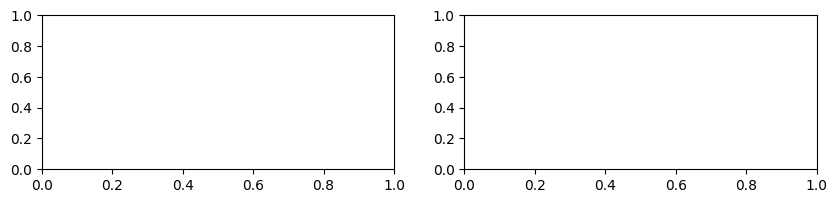

In [ ]:
color=['orange', 'blue']

fig = plt.figure(figsize=(10,2))
ax0 = fig.add_subplot(121)
ax1 = fig.add_subplot(122)
for i in range(500):
    ax0.plot(t_span, trajectory[:,i,0], color=color[int(yn[i])], alpha=.1);
    ax1.plot(t_span, trajectory[:,i,1], color=color[int(yn[i])], alpha=.1);
ax0.set_xlabel(r"$t$ [Depth]") ; ax0.set_ylabel(r"$h_0(t)$")
ax1.set_xlabel(r"$t$ [Depth]") ; ax1.set_ylabel(r"$z_1(t)$")
ax0.set_title("Dimension 0") ; ax1.set_title("Dimension 1")

Then the trajectory in the *state-space*

As you can see, the Neural ODE steers the data-points into regions of null loss with a continuous flow in the depth domain. Finally, we can also plot the learned vector field $f$

In [ ]:
# evaluate vector field
n_pts = 50
x = torch.linspace(trajectory[:,:,0].min(), trajectory[:,:,0].max(), n_pts)
y = torch.linspace(trajectory[:,:,1].min(), trajectory[:,:,1].max(), n_pts)
X, Y = torch.meshgrid(x, y) ; z = torch.cat([X.reshape(-1,1), Y.reshape(-1,1)], 1)
f = model.vf(0,z.to(device)).cpu().detach()
fx, fy = f[:,0], f[:,1] ; fx, fy = fx.reshape(n_pts , n_pts), fy.reshape(n_pts, n_pts)
# plot vector field and its intensity
fig = plt.figure(figsize=(4, 4)) ; ax = fig.add_subplot(111)
ax.streamplot(X.numpy().T, Y.numpy().T, fx.numpy().T, fy.numpy().T, color='black')
ax.contourf(X.T, Y.T, torch.sqrt(fx.T**2+fy.T**2), cmap='RdYlBu')

NameError: name 'trajectory' is not defined

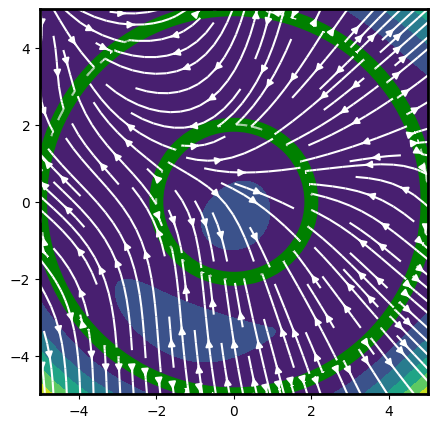

In [ ]:
import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Circle

# Assuming 'model', 'device', and 'trajectory' are already defined in your environment

# Evaluate vector field
n_pts = 100
x = torch.linspace(-5, 5, n_pts)  # Set range from -5 to 5
y = torch.linspace(-5, 5, n_pts)  # Set range from -5 to 5
X, Y = torch.meshgrid(x, y)
z = torch.cat([X.reshape(-1,1), Y.reshape(-1,1)], 1)
f = model.vf(0, z.to(device)).cpu().detach()
fx, fy = f[:,0], f[:,1]
fx, fy = fx.reshape(n_pts, n_pts), fy.reshape(n_pts, n_pts)

# Plot vector field and its intensity
fig = plt.figure(figsize=(5, 5))  # Set figure size to 5x5 inches
ax = fig.add_subplot(111)

# Vector field
ax.streamplot(X.numpy().T, Y.numpy().T, fx.numpy().T, fy.numpy().T, color='white')

# Contour plot with a continuous color map (e.g., 'viridis')
contour = ax.contourf(X.T, Y.T, torch.sqrt(fx.T**2 + fy.T**2), cmap='viridis')

# Set axis limits to [-5, 5] in both directions
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

# Increase the width of the axis lines
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

# Add a circle of radius 2
circle = Circle((0, 0), 2, color='green', fill=False, linewidth = 10)
ax.add_patch(circle)

# Add a circle of radius 5
circle2 = Circle((0, 0), 5, color='green', fill=False, linewidth = 10)
ax.add_patch(circle2)

plt.show()


In [ ]:
A

In [ ]:
import torch.optim as optim

# Define points A and B
radius = 3.5  # Radius of the smaller circle
A = torch.tensor([3.5, 0], dtype=torch.float32).to(device)  # Point on one side of the circle
B = torch.tensor([-4.5, 0], dtype=torch.float32).to(device)  # Diametrically opposite point

# Define model, assuming 'model' is already defined and moved to 'device'
# model = YourModel().to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
n_epochs = 1000  # Number of epochs
for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Generate trajectory from point A, assuming 'trajectory' is a function you've defined
    # The function should return the end point of the trajectory starting from A
    traj_A = model.trajectory(A.unsqueeze(0), t_span)

    # Compute MSE Loss
    loss = torch.nn.functional.mse_loss(traj_A[-1], B)

    # Backpropagation
    loss.backward()
    optimizer.step()

    # Print loss every few epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")


<ipython-input-29-3ee4338445a6>:24: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = torch.nn.functional.mse_loss(traj_A[-1], B)


Epoch 0, Loss: 27.370189666748047
Epoch 10, Loss: 21.23326873779297
Epoch 20, Loss: 18.738676071166992
Epoch 30, Loss: 13.69328498840332
Epoch 40, Loss: 6.909946441650391
Epoch 50, Loss: 1.143426537513733
Epoch 60, Loss: 0.06047398969531059
Epoch 70, Loss: 0.008033739402890205
Epoch 80, Loss: 0.010539472103118896
Epoch 90, Loss: 0.010511730797588825
Epoch 100, Loss: 0.00798401702195406
Epoch 110, Loss: 0.00518727907910943
Epoch 120, Loss: 0.002741018543019891


KeyboardInterrupt: 

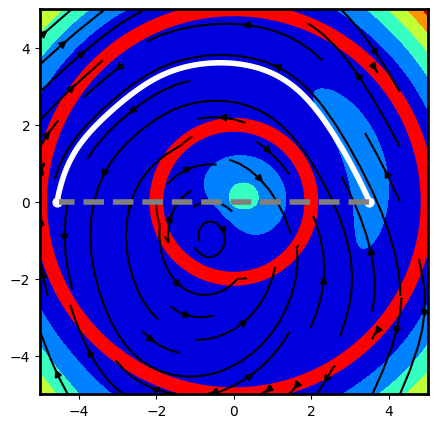

In [ ]:
import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Circle

# Assuming 'model', 'device', and 'trajectory' are already defined in your environment

# Evaluate vector field
n_pts = 100
x = torch.linspace(-5, 5, n_pts)  # Set range from -5 to 5
y = torch.linspace(-5, 5, n_pts)  # Set range from -5 to 5
X, Y = torch.meshgrid(x, y)
z = torch.cat([X.reshape(-1,1), Y.reshape(-1,1)], 1)
f = model.vf(0, z.to(device)).cpu().detach()
fx, fy = f[:,0], f[:,1]
fx, fy = fx.reshape(n_pts, n_pts), fy.reshape(n_pts, n_pts)

# Plot vector field and its intensity
fig = plt.figure(figsize=(5, 5))  # Set figure size to 5x5 inches
ax = fig.add_subplot(111)

# Vector field
ax.streamplot(X.numpy().T, Y.numpy().T, fx.numpy().T, fy.numpy().T, color='black', density = 0.5)

# Contour plot with a continuous color map (e.g., 'viridis')
contour = ax.contourf(X.T, Y.T, torch.sqrt(fx.T**2 + fy.T**2), cmap='jet')
plt.plot(traj_A.detach().cpu().squeeze(1)[:, 0], traj_A.detach().cpu().squeeze(1)[:, 1], linewidth = 4, color = "white")

# Set axis limits to [-5, 5] in both directions
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

# Increase the width of the axis lines
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

# Add a circle of radius 2
circle = Circle((0, 0), 2, color='red', fill=False, linewidth = 10)
ax.add_patch(circle)

# Add a circle of radius 5
circle2 = Circle((0, 0), 5, color='red', fill=False, linewidth = 10)
ax.add_patch(circle2)

plt.plot([A[0], B[0]], [A[1], B[1]], linestyle = "--", linewidth = 4, color = "grey")
plt.scatter(traj_A.detach().cpu().squeeze(1)[0, 0], traj_A.detach().cpu().squeeze(1)[0, 1], color = "white", s = 40)
plt.scatter(traj_A.detach().cpu().squeeze(1)[-1, 0], traj_A.detach().cpu().squeeze(1)[-1, 1], color = "white", s= 40)


plt.show()


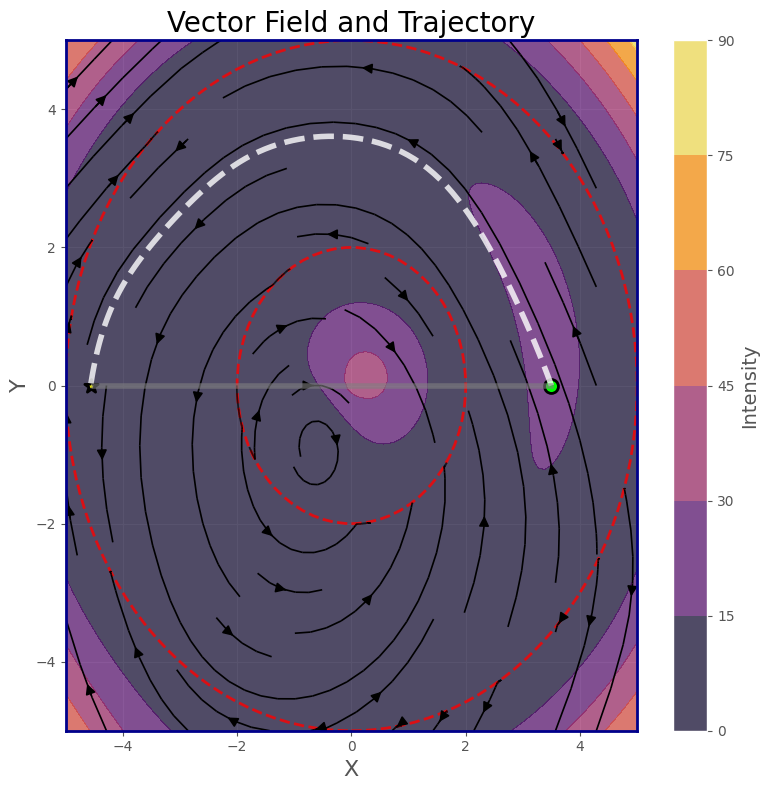

In [ ]:
import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Circle

# Assuming 'model', 'device', and 'trajectory' are already defined in your environment

# Evaluate vector field
n_pts = 100
x = torch.linspace(-5, 5, n_pts)  # Set range from -5 to 5
y = torch.linspace(-5, 5, n_pts)  # Set range from -5 to 5
X, Y = torch.meshgrid(x, y)
z = torch.cat([X.reshape(-1,1), Y.reshape(-1,1)], 1)
f = model.vf(0, z.to(device)).cpu().detach()
fx, fy = f[:,0], f[:,1]
fx, fy = fx.reshape(n_pts, n_pts), fy.reshape(n_pts, n_pts)

# Plot vector field and its intensity
fig = plt.figure(figsize=(8, 8))  # Increase figure size to 8x8 inches
ax = fig.add_subplot(111)

# change
plt.set_cmap('inferno')

# Vector field with a custom color map and increased arrow size
ax.streamplot(X.numpy().T, Y.numpy().T, fx.numpy().T, fy.numpy().T, color='black', density=0.5, arrowsize=1.5, linewidth=1.2, cmap='warm')

# Contour plot with a custom color map and increased transparency
contour = ax.contourf(X.T, Y.T, torch.sqrt(fx.T**2 + fy.T**2), cmap='inferno', alpha=0.7)

# Plot the trajectory with a custom line style and color
plt.plot(traj_A.detach().cpu().squeeze(1)[:, 0], traj_A.detach().cpu().squeeze(1)[:, 1], linewidth=4, color='white', linestyle='--', alpha=0.8)

# Set axis limits to [-5, 5] in both directions
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

# Increase the width of the axis lines and add a custom color
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)
    ax.spines[axis].set_color('darkblue')

# Add a circle of radius 2 with a custom line style and color
circle = Circle((0, 0), 2, color='red', fill=False, linewidth=2, linestyle='--', alpha=0.8)
ax.add_patch(circle)

# Add a circle of radius 5 with a custom line style and color
circle2 = Circle((0, 0), 5, color='red', fill=False, linewidth=2, linestyle='--', alpha=0.8)
ax.add_patch(circle2)

# Plot the start and end points with custom markers and sizes
plt.plot([A[0], B[0]], [A[1], B[1]], linestyle="-", linewidth=4, color="grey", alpha=0.6)
plt.scatter(traj_A.detach().cpu().squeeze(1)[0, 0], traj_A.detach().cpu().squeeze(1)[0, 1], color="lime", s=100, marker='o', edgecolors='black', linewidths=2)
plt.scatter(traj_A.detach().cpu().squeeze(1)[-1, 0], traj_A.detach().cpu().squeeze(1)[-1, 1], color="yellow", s=100, marker='*', edgecolors='black', linewidths=2)

# Set custom labels and title with increased font sizes
plt.xlabel('X', fontsize=16)
plt.ylabel('Y', fontsize=16)
plt.title('Vector Field and Trajectory', fontsize=20)

# Add a color bar with a label
cbar = plt.colorbar(contour)
cbar.set_label('Intensity', fontsize=14)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
traj_A.detach().cpu().squeeze(1).shape

In [ ]:
import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Circle

# Assuming 'model', 'device', and 'trajectory' are already defined in your environment

# Evaluate vector field
n_pts = 50
x = torch.linspace(-5, 5, n_pts)
y = torch.linspace(-5, 5, n_pts)
X, Y = torch.meshgrid(x, y)
z = torch.cat([X.reshape(-1,1), Y.reshape(-1,1)], 1)
f = model.vf(0, z.to(device)).cpu().detach()
fx, fy = f[:,0], f[:,1]
fx, fy = fx.reshape(n_pts, n_pts), fy.reshape(n_pts, n_pts)

# Plot vector field and its intensity
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

# Vector field
ax.streamplot(X.numpy().T, Y.numpy().T, fx.numpy().T, fy.numpy().T, color='black')

# Contour plot with a continuous color map (e.g., 'viridis')
contour = ax.contourf(X.T, Y.T, torch.sqrt(fx.T**2 + fy.T**2), cmap='viridis')

# Set axis limits to [-5, 5] in both directions
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

# Increase the width of the axis lines
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

# Add a circle of radius 3
circle = Circle((0, 0), 1, color='blue', fill=False)
ax.add_patch(circle)

# Highlight zero flow points
zero_flow_threshold = 1e-2  # Define a threshold for zero flow
zero_flow_x, zero_flow_y = X[(fx.abs() < zero_flow_threshold) & (fy.abs() < zero_flow_threshold)], \
                           Y[(fx.abs() < zero_flow_threshold) & (fy.abs() < zero_flow_threshold)]

print(zero_flow_x)
ax.scatter(zero_flow_x, zero_flow_y, color='red', s=10)  # Plot them in red

plt.show()


**Sweet! You trained your first Neural ODEs! Now you can proceed and learn about more advanced models with the next tutorials**

## More about `torchdyn`


In [ ]:
import time
from torchdyn.numerics import Euler, RungeKutta4, Tsitouras45, DormandPrince45, MSZero, Euler, HyperEuler
from torchdyn.numerics import odeint, odeint_mshooting, Lorenz
from torchdyn.core import ODEProblem, MultipleShootingProblem

But wait! `torchdyn` has way more than `NeuralODEs`. If you wish to solve generic differential equations parallelizable both in space (initial conditions) as well in time, with parallel, but do not need neural networks inside the vector field, you can use our functional API like so:

In [ ]:
x0 = torch.randn(8, 3) + 15
t_span = torch.linspace(0, 3, 2000)
sys = Lorenz()

In [ ]:
t0 = time.time()
t_eval, accurate_sol = odeint(sys, x0, t_span, solver='dopri5', atol=1e-6, rtol=1e-6)
accurate_sol_time = time.time() - t0

t0 = time.time()
t_eval, base_sol = odeint(sys, x0, t_span, solver='euler')
base_sol_time = time.time() - t0

t0 = time.time()
t_eval, rk4_sol = odeint(sys, x0, t_span, solver='rk4')
rk4_sol_time = time.time() - t0

t0 = time.time()
t_eval, dp5_low_sol = odeint(sys, x0, t_span, solver='dopri5', atol=1e-3, rtol=1e-3)
dp5_low_time = time.time() - t0

t0 = time.time()
t_eval, ms_sol = odeint_mshooting(sys, x0, t_span, solver='mszero', fine_steps=2, maxiter=4)
ms_sol_time = time.time() - t0

Alternatively, you can wrap your vector field in a specific `*Problem` to perform sensitivity analysis and optimize for terminal as well as integral objectives:

In [ ]:
prob = ODEProblem(sys, sensitivity='interpolated_adjoint', solver='dopri5', atol=1e-3, rtol=1e-3,
                  solver_adjoint='tsit5', atol_adjoint=1e-3, rtol_adjoint=1e-3)
t0 = time.time()
t_eval, sol_torchdyn = prob.odeint(x0, t_span)
t_end1 = time.time() - t0

Our numerics suite includes other tools, such as a `odeint_hybrid` for hybrid systems (potentially stochastic and multi-mode). We have built our numerics suite from the ground up to be compatible with hybridized methods such as hypersolvers, where a base solver works in tandem with neural approximators to increase accuracy while retaining improved extrapolation capabilities. In fact, these methods can be called from the same API:

In [ ]:
class VanillaHyperNet(nn.Module):
    def __init__(self, net):
        super().__init__()
        self.net = net
        for p in self.net.parameters():
            torch.nn.init.uniform_(p, 0, 1e-5)
    def forward(self, t, x):
        return self.net(x)

In [ ]:
net = nn.Sequential(nn.Linear(3, 64), nn.Softplus(), nn.Linear(64, 64), nn.Softplus(), nn.Linear(64, 3))
hypersolver = HyperEuler(VanillaHyperNet(net))
t_eval, sol = odeint(sys, x0, t_span, solver=hypersolver) # note: this has to be trained!

We also provide an extensive set of tutorial subdivided into modules. Each tutorials deals with a specific aspect of continuous or implicit models, or showcases applications (control, generative modeling, forecasting, optimal control of ODEs and PDEs, graph node classification). Check `torchdyn/tutorials` for more information.